In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("benchmark_dataset_full.csv")

df["hit_rate"] = df["hits_real"] / df["queries_real"]
df = df[df["queries_real"] > 0]

df = df.sort_values(["mode", "max_chat_len", "run"])


In [3]:
agg = (
    df
    .groupby(["mode", "max_chat_len"])
    .agg(
        hit_rate_mean=("hit_rate", "mean"),
        hit_rate_std=("hit_rate", "std"),
        queries_mean=("queries_real", "mean"),
        hits_mean=("hits_real", "mean"),
        input_tokens_mean=("total_input_tokens", "mean"),
        output_tokens_mean=("total_output_tokens", "mean"),
    )
    .reset_index()
)


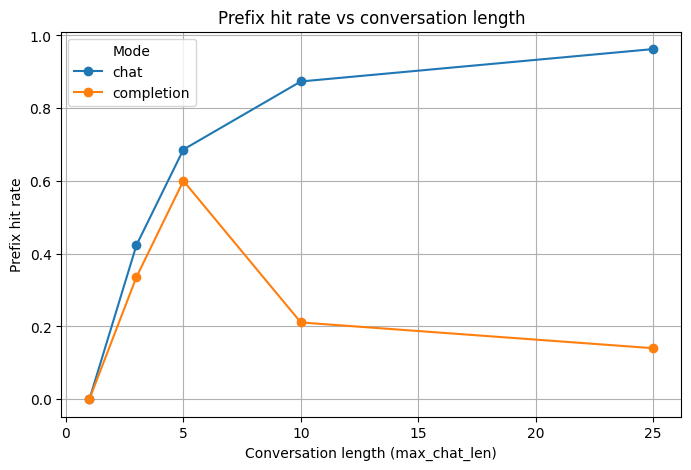

In [4]:
plt.figure(figsize=(8, 5))

for mode in agg["mode"].unique():
    sub = agg[agg["mode"] == mode]
    plt.plot(
        sub["max_chat_len"],
        sub["hit_rate_mean"],
        marker="o",
        label=mode
    )

plt.xlabel("Conversation length (max_chat_len)")
plt.ylabel("Prefix hit rate")
plt.title("Prefix hit rate vs conversation length")
plt.legend(title="Mode")
plt.grid(True)
plt.show()


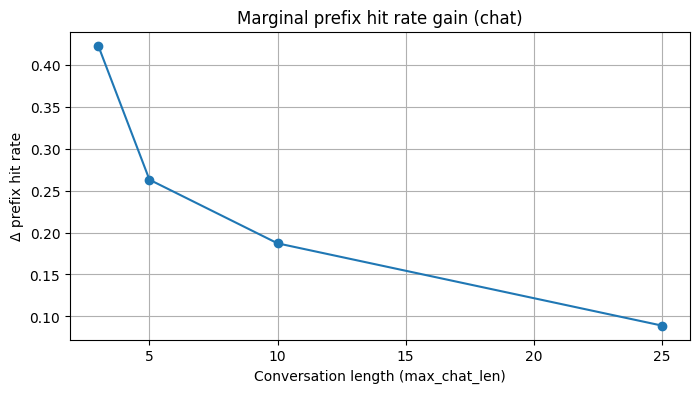

In [5]:
chat = agg[agg["mode"] == "chat"].copy()
chat["delta_hit_rate"] = chat["hit_rate_mean"].diff()

plt.figure(figsize=(8, 4))
plt.plot(
    chat["max_chat_len"],
    chat["delta_hit_rate"],
    marker="o"
)

plt.xlabel("Conversation length (max_chat_len)")
plt.ylabel("Δ prefix hit rate")
plt.title("Marginal prefix hit rate gain (chat)")
plt.grid(True)
plt.show()


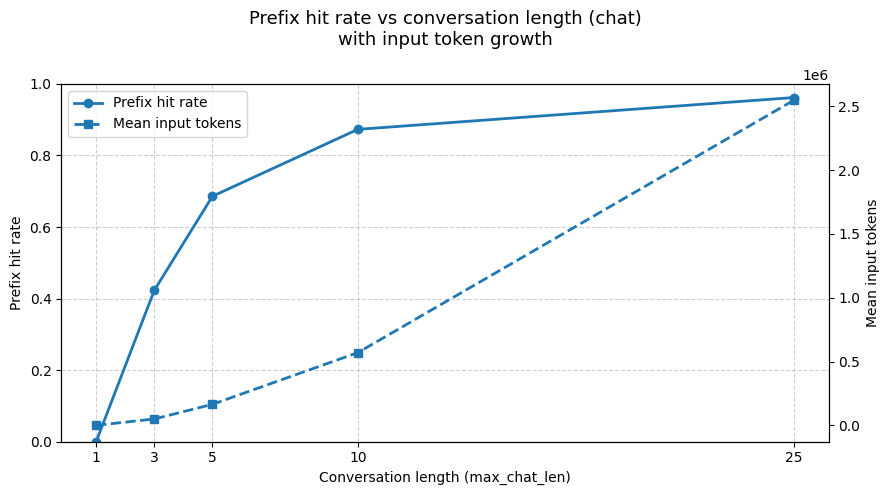

In [9]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# Prefix hit rate (eixo esquerdo)
ax1.plot(
    chat["max_chat_len"],
    chat["hit_rate_mean"],
    marker="o",
    linewidth=2,
    label="Prefix hit rate"
)
ax1.set_xlabel("Conversation length (max_chat_len)")
ax1.set_ylabel("Prefix hit rate")
ax1.set_ylim(0, 1)
ax1.set_xticks(chat["max_chat_len"])
ax1.grid(True, which="both", linestyle="--", alpha=0.6)

# Input tokens (eixo direito)
ax2 = ax1.twinx()
ax2.plot(
    chat["max_chat_len"],
    chat["input_tokens_mean"],
    linestyle="--",
    marker="s",
    linewidth=2,
    label="Mean input tokens"
)
ax2.set_ylabel("Mean input tokens")

# Título
fig.suptitle(
    "Prefix hit rate vs conversation length (chat)\n"
    "with input token growth",
    fontsize=13
)

# Legenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()


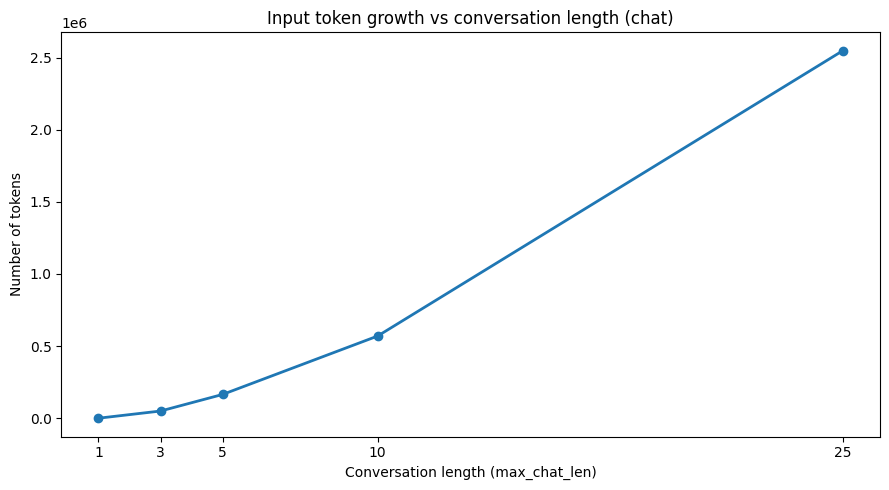

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    chat["max_chat_len"],
    chat["input_tokens_mean"],
    marker="o",
    linewidth=2,
    label="Mean input tokens"
)


plt.xlabel("Conversation length (max_chat_len)")
plt.ylabel("Number of tokens")
plt.title("Input token growth vs conversation length (chat)")
plt.xticks(chat["max_chat_len"])

plt.tight_layout()
plt.show()


In [22]:
df = df.copy()

df["hit_rate"] = df["hits_real"] / df["queries_real"]

means = (
    df
    .groupby(["mode", "max_chat_len"])
    .agg(
        hit_rate_mean=("hit_rate", "mean"),
        total_input_tokens_mean=("total_input_tokens", "mean"),
        total_output_tokens_mean=("total_output_tokens", "mean"),
    )
    .reset_index()
)

df_var = df.merge(
    means,
    on=["mode", "max_chat_len"],
    how="left"
)

df_var["hit_rate_var"] = (
    100 * (df_var["hit_rate"] - df_var["hit_rate_mean"])
    / df_var["hit_rate_mean"]
)

df_var["input_var"] = (
    100 * (df_var["total_input_tokens"] - df_var["total_input_tokens_mean"])
    / df_var["total_input_tokens_mean"]
)

df_var["output_var"] = (
    100 * (df_var["total_output_tokens"] - df_var["total_output_tokens_mean"])
    / df_var["total_output_tokens_mean"]
)
summary_by_experiment = (
    df_var
    .groupby(["mode", "max_chat_len"])
    .agg(
        hit_rate_var=(
            "hit_rate_var",
            lambda x: x.abs().mean()
        ),
        input_var=(
            "input_var",
            lambda x: x.abs().mean()
        ),
        output_var=(
            "output_var",
            lambda x: x.abs().mean()
        ),
    )
    .reset_index()
    .sort_values(["mode", "max_chat_len"])
)

summary_by_experiment


,mode,max_chat_len,hit_rate_var,input_var,output_var
0,chat,1,NaN,0.000000,0.039280
1,chat,3,3.488260,1.610136,1.024369
2,chat,5,0.899687,0.304371,0.814982
3,chat,10,0.867250,2.538285,2.872944
4,chat,25,0.393991,2.538389,2.378128
5,completion,1,NaN,0.000000,0.000000
6,completion,3,0.009406,0.024298,0.013385
7,completion,5,0.005946,0.000633,0.000000
8,completion,10,0.726810,0.002062,0.000000
9,completion,25,8.302609,0.001960,0.000000
